# Adaptive Window Size Grid Search (cpd_bayesian)

Grid search over `(w_min, w_max)` combinations using EWMA-based adaptive window
for the **BOCPD + OLS** (`cpd_bayesian`) method.

- `w_min` in {3, 4, 5}
- `w_max` in {8, 10, 12, 15}

For each combo, run adaptive BOCPD+OLS on all arrival datasets and record MSE/MAE.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import itertools
import warnings
warnings.filterwarnings('ignore')

from src.booles_cpd_predictor import BOOLES_cpdPredictor

BASE_DIR = '/Users/qianxinhui/Desktop/Misc/2026/NU-Research/kellogg/change-point-detection'
os.chdir(BASE_DIR)

ARRIVAL_DIR = os.path.join(BASE_DIR, 'data_integrated/arrival_data')
SAVE_DIR = os.path.join(BASE_DIR, 'data_integrated/result_data/M=500')
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
# --- Grid search configuration ---
W_MINS = [3, 4, 5]
W_MAXS = [8, 10, 12, 15]
METHODS = ['ols']
LAMBDA = 0.94  # EWMA decay factor

# BOCPD hyperparameters (keep consistent across grid search)
BOCPD_PARAMS = dict(
    hazard_lambda=100,
    mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0,
    alarm_threshold=0.7, alarm_min_consecutive=1,
)

# Collect arrival data files — strictly 500 samples (exclude 5000)
import re
all_files = sorted([
    f for f in os.listdir(ARRIVAL_DIR)
    if f.endswith('.csv') and re.search(r'samples_500(?!\d)', f)
])
print(f'Found {len(all_files)} arrival data files')
for f in all_files:
    print(f'  {f}')

Found 25 arrival data files
  initial_value_5_samples_500.csv
  initial_value_5_samples_500_a_0.1_b_100_delta_0.5.csv
  initial_value_5_samples_500_a_0.2_b_150_delta_2.0.csv
  initial_value_5_samples_500_a_0.3_b_120_delta_1.0.csv
  initial_value_5_samples_500_a_0.3_b_150.csv
  initial_value_5_samples_500_a_0.4_b_110_delta_0.1.csv
  initial_value_5_samples_500_a_0.4_b_120.csv
  initial_value_5_samples_500_a_0.4_b_130.csv
  initial_value_5_samples_500_a_0.5_b_120.csv
  initial_value_5_samples_500_a_0.5_b_130_delta_10.csv
  initial_value_5_samples_500_a_0.5_b_130_delta_3.0.csv
  initial_value_5_samples_500_a_0.5_b_130_delta_5.0.csv
  initial_value_5_samples_500_a_0.6_b_100.csv
  initial_value_5_samples_500_a_0.6_b_90_delta_1.5.csv
  initial_value_5_samples_500_a_0.8_b_100.csv
  initial_value_5_samples_500_a_0.8_b_80_delta_0.3.csv
  initial_value_5_samples_500_a_1.0_b_80.csv
  initial_value_80_samples_500.csv
  initial_value_80_samples_500_a_0.1_b_100_delta_0.5.csv
  initial_value_80_sampl

In [3]:
# --- Run grid search (adaptive cpd_bayesian) ---
results = []
total = len(all_files) * len(W_MINS) * len(W_MAXS) * len(METHODS)
count = 0

for file in all_files:
    data_raw = pd.read_csv(os.path.join(ARRIVAL_DIR, file))
    if 'initial_value_5' in file:
        z0 = 5
    elif 'initial_value_80' in file:
        z0 = 80
    else:
        continue

    for w_min, w_max in itertools.product(W_MINS, W_MAXS):
        for method in METHODS:
            count += 1
            tag = f'Z0={z0} | w_min={w_min}, w_max={w_max} | {method} | {file}'
            if count % 10 == 0 or count == 1:
                print(f'[{count}/{total}] {tag}')

            try:
                # Fresh predictor for each run (BOCPD state resets)
                predictor = BOOLES_cpdPredictor(**BOCPD_PARAMS)
                metrics = predictor.adaptive_rolling_prediction(
                    data_raw.copy(),
                    w_min=w_min, w_max=w_max,
                    method=method, plot=False,
                    lambda_=LAMBDA
                )

                if metrics is not None:
                    avg_ws = (np.mean([w for _, w in predictor.window_sizes_used])
                              if predictor.window_sizes_used else np.nan)
                    n_steps = len(predictor.window_sizes_used)
                    results.append({
                        'file': file, 'z0': z0, 'method': method,
                        'w_min': w_min, 'w_max': w_max,
                        'mse': metrics['mse'], 'rmse': metrics['rmse'],
                        'mae': metrics['mae'], 'mape': metrics['mape'],
                        'direction_accuracy': metrics['direction_accuracy'],
                        'avg_changepoint_prob': metrics['avg_changepoint_prob'],
                        'avg_window_size': avg_ws,
                        'n_steps': n_steps,
                    })
                else:
                    results.append({
                        'file': file, 'z0': z0, 'method': method,
                        'w_min': w_min, 'w_max': w_max,
                        'mse': np.nan, 'rmse': np.nan,
                        'mae': np.nan, 'mape': np.nan,
                        'direction_accuracy': np.nan,
                        'avg_changepoint_prob': np.nan,
                        'avg_window_size': np.nan,
                        'n_steps': np.nan,
                    })
            except Exception as e:
                print(f'  ERROR: {tag} -> {e}')
                results.append({
                    'file': file, 'z0': z0, 'method': method,
                    'w_min': w_min, 'w_max': w_max,
                    'mse': np.nan, 'rmse': np.nan,
                    'mae': np.nan, 'mape': np.nan,
                    'direction_accuracy': np.nan,
                    'avg_changepoint_prob': np.nan,
                    'avg_window_size': np.nan,
                    'n_steps': np.nan,
                })

print(f'\nDone! {len(results)} runs completed.')

[1/300] Z0=5 | w_min=3, w_max=8 | ols | initial_value_5_samples_500.csv
Running online BOCPD...
  1/501, CP prob=0.0000
  101/501, CP prob=0.0125
  201/501, CP prob=0.0150
  301/501, CP prob=0.0207
  401/501, CP prob=0.0160
  501/501, CP prob=0.0156
Running adaptive windowed prediction...
Running online BOCPD...
  1/501, CP prob=0.0000
  101/501, CP prob=0.0125
  201/501, CP prob=0.0150
  301/501, CP prob=0.0207
  401/501, CP prob=0.0160
  501/501, CP prob=0.0156
Running adaptive windowed prediction...
Running online BOCPD...
  1/501, CP prob=0.0000
  101/501, CP prob=0.0125
  201/501, CP prob=0.0150
  301/501, CP prob=0.0207
  401/501, CP prob=0.0160
  501/501, CP prob=0.0156
Running adaptive windowed prediction...
Running online BOCPD...
  1/501, CP prob=0.0000
  101/501, CP prob=0.0125
  201/501, CP prob=0.0150
  301/501, CP prob=0.0207
  401/501, CP prob=0.0160
  501/501, CP prob=0.0156
Running adaptive windowed prediction...
Running online BOCPD...
  1/501, CP prob=0.0000
  101/50

In [4]:
# --- Build results DataFrame ---
df = pd.DataFrame(results)
df.to_csv(os.path.join(SAVE_DIR, 'adaptive_cpd_bayesian_grid_search_results.csv'), index=False)
print(f'Results shape: {df.shape}')
df.head(10)

Results shape: (300, 13)


,file,z0,method,w_min,w_max,mse,rmse,mae,mape,direction_accuracy,avg_changepoint_prob,avg_window_size,n_steps
0,initial_value_5_samples_500.csv,5,ols,3,8,10.409301,3.226345,2.419151,4.687786,56.400000,0.01782,7.781250,64.0
1,initial_value_5_samples_500.csv,5,ols,3,10,16.438864,4.054487,3.085469,5.649267,52.610442,0.01782,9.725490,51.0
2,initial_value_5_samples_500.csv,5,ols,3,12,21.051265,4.588166,3.209816,5.920175,51.903808,0.01782,11.558140,43.0
3,initial_value_5_samples_500.csv,5,ols,3,15,20.690602,4.548692,3.462904,6.256788,56.827309,0.01782,14.171429,35.0
4,initial_value_5_samples_500.csv,5,ols,4,8,12.234768,3.497823,2.578386,4.886985,50.600000,0.01782,7.888889,63.0
5,initial_value_5_samples_500.csv,5,ols,4,10,11.788902,3.433497,2.688297,5.143349,55.200000,0.01782,9.745098,51.0
6,initial_value_5_samples_500.csv,5,ols,4,12,14.336007,3.786292,2.870997,5.352080,55.400000,0.01782,11.558140,43.0
7,initial_value_5_samples_500.csv,5,ols,4,15,20.858976,4.567163,3.208730,5.833453,53.000000,0.01782,14.200000,35.0
8,initial_value_5_samples_500.csv,5,ols,5,8,10.925009,3.305300,2.486532,4.988208,55.400000,0.01782,7.873016,63.0
9,initial_value_5_samples_500.csv,5,ols,5,10,17.510918,4.184605,3.000467,5.487176,52.822581,0.01782,9.840000,50.0


In [5]:
# --- Summary: Mean MSE by (w_min, w_max, method) averaged across all files ---
summary = df.groupby(['method', 'w_min', 'w_max']).agg(
    mse_mean=('mse', 'mean'),
    mse_std=('mse', 'std'),
    mae_mean=('mae', 'mean'),
    rmse_mean=('rmse', 'mean'),
    avg_ws_mean=('avg_window_size', 'mean'),
    dir_acc_mean=('direction_accuracy', 'mean'),
).reset_index()

summary = summary.sort_values(['method', 'mse_mean'])
print('=== Overall Summary (sorted by MSE) ===')
summary

=== Overall Summary (sorted by MSE) ===


,method,w_min,w_max,mse_mean,mse_std,mae_mean,rmse_mean,avg_ws_mean,dir_acc_mean
5,ols,4,10,59.641667,96.721064,4.396613,5.930058,9.447118,54.253689
0,ols,3,8,60.282437,112.304960,4.252577,5.680253,7.567738,54.134773
4,ols,4,8,65.867630,137.249858,4.372545,5.906314,7.698638,53.641681
8,ols,5,8,66.416190,145.466057,4.289305,5.780858,7.816414,54.183514
9,ols,5,10,66.698538,116.201725,4.566727,6.125295,9.585014,54.253355
1,ols,3,10,72.487167,130.191470,4.680845,6.309200,9.339740,54.302158
10,ols,5,12,80.178741,136.190557,5.061706,6.779972,11.356927,54.074159
2,ols,3,12,82.737492,137.851479,5.109982,6.898766,11.047148,54.125333
6,ols,4,12,88.933245,165.432288,5.114446,6.955211,11.165811,54.375821
3,ols,3,15,91.956682,165.838648,5.413650,7.235422,13.516609,54.684103


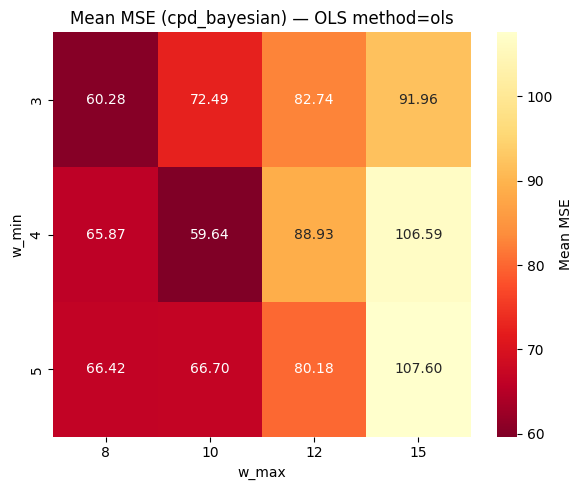

In [6]:
# --- Heatmap: MSE by (w_min, w_max) for each method ---
fig, axes = plt.subplots(1, len(METHODS), figsize=(6 * len(METHODS), 5))
if len(METHODS) == 1:
    axes = [axes]

for ax, method in zip(axes, METHODS):
    sub = summary[summary['method'] == method]
    pivot = sub.pivot(index='w_min', columns='w_max', values='mse_mean')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd_r', ax=ax,
                cbar_kws={'label': 'Mean MSE'})
    ax.set_title(f'Mean MSE (cpd_bayesian) — OLS method={method}')
    ax.set_xlabel('w_max')
    ax.set_ylabel('w_min')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'adaptive_cpd_bayesian_mse_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

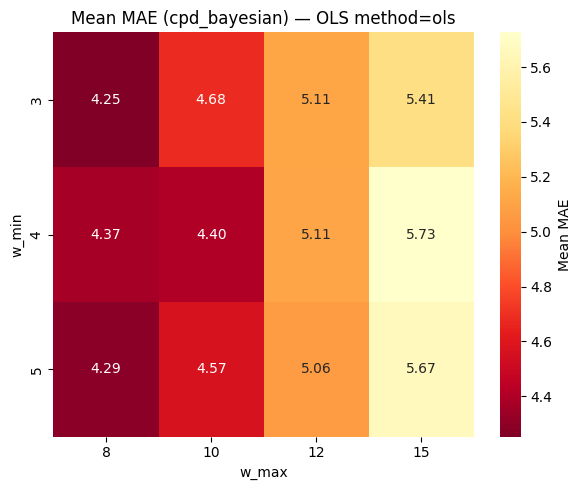

In [7]:
# --- Heatmap: MAE by (w_min, w_max) for each method ---
fig, axes = plt.subplots(1, len(METHODS), figsize=(6 * len(METHODS), 5))
if len(METHODS) == 1:
    axes = [axes]

for ax, method in zip(axes, METHODS):
    sub = summary[summary['method'] == method]
    pivot = sub.pivot(index='w_min', columns='w_max', values='mae_mean')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd_r', ax=ax,
                cbar_kws={'label': 'Mean MAE'})
    ax.set_title(f'Mean MAE (cpd_bayesian) — OLS method={method}')
    ax.set_xlabel('w_max')
    ax.set_ylabel('w_min')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'adaptive_cpd_bayesian_mae_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# --- Split by Z0: see if optimal (w_min, w_max) differs by initial value ---
for z0_val in sorted(df['z0'].unique()):
    print(f'\n{"="*60}')
    print(f'Z0 = {z0_val}')
    print('='*60)
    sub = df[df['z0'] == z0_val]
    s = sub.groupby(['method', 'w_min', 'w_max']).agg(
        mse_mean=('mse', 'mean'),
        mae_mean=('mae', 'mean'),
        avg_ws=('avg_window_size', 'mean'),
        dir_acc=('direction_accuracy', 'mean'),
    ).reset_index().sort_values(['method', 'mse_mean'])

    for method in METHODS:
        ms = s[s['method'] == method].head(5)
        print(f'\n  Top 5 for method={method}:')
        print(ms.to_string(index=False))


Z0 = 5

  Top 5 for method=ols:
method  w_min  w_max  mse_mean  mae_mean   avg_ws   dir_acc
   ols      3      8 68.821954  4.516397 7.773898 56.045923
   ols      4     10 69.105306  4.669956 9.677376 56.050000
   ols      5     10 76.041869  4.852494 9.803921 55.214570
   ols      5      8 77.728818  4.566141 7.908170 56.297302
   ols      4      8 82.112926  4.784601 7.870505 55.045165

Z0 = 80

  Top 5 for method=ols:
method  w_min  w_max  mse_mean  mae_mean   avg_ws   dir_acc
   ols      4      8 33.377039  3.548434 7.354906 50.834712
   ols      4     10 40.714389  3.849927 8.986601 50.661066
   ols      3      8 43.203401  3.724937 7.155417 50.312474
   ols      5      8 43.790935  3.735633 7.632902 49.955938
   ols      3     10 46.288684  3.906149 8.798686 51.813026


In [10]:
# --- Compare adaptive vs fixed window (cpd_bayesian baseline) ---
fixed_ws_list = [3, 4, 5, 8, 10, 12, 15]
baseline_results = []

for file in all_files:
    data_raw = pd.read_csv(os.path.join(ARRIVAL_DIR, file))
    z0 = 5 if 'initial_value_5' in file else (80 if 'initial_value_80' in file else None)
    if z0 is None:
        continue

    for ws in fixed_ws_list:
        for method in METHODS:
            try:
                predictor = BOOLES_cpdPredictor(**BOCPD_PARAMS)
                metrics = predictor.rolling_prediction(
                    data_raw.copy(), window_size=ws,
                    method=method, plot=False,
                    cpd_method='bayesian'
                )
                if metrics is not None:
                    baseline_results.append({
                        'file': file, 'z0': z0, 'method': method,
                        'window_size': ws,
                        'mse': metrics['mse'], 'mae': metrics['mae'],
                        'rmse': metrics['rmse'],
                        'direction_accuracy': metrics['direction_accuracy'],
                        'type': 'fixed'
                    })
            except Exception as e:
                print(f'  Baseline ERROR: ws={ws}, {method}, {file} -> {e}')

df_baseline = pd.DataFrame(baseline_results)
df_baseline.to_csv(os.path.join(SAVE_DIR, 'fixed_cpd_bayesian_baseline_results.csv'), index=False)
print(f'Baseline runs: {len(df_baseline)}')

Running online BOCPD...
  1/501, CP prob=0.0000
  51/501, CP prob=0.0127
  101/501, CP prob=0.0125
  151/501, CP prob=0.0170
  201/501, CP prob=0.0150
  251/501, CP prob=0.0198
  301/501, CP prob=0.0207
  351/501, CP prob=0.0242
  401/501, CP prob=0.0160
  451/501, CP prob=0.0338
  501/501, CP prob=0.0156
Running windowed prediction...
Running online BOCPD...
  1/501, CP prob=0.0000
  51/501, CP prob=0.0127
  101/501, CP prob=0.0125
  151/501, CP prob=0.0170
  201/501, CP prob=0.0150
  251/501, CP prob=0.0198
  301/501, CP prob=0.0207
  351/501, CP prob=0.0242
  401/501, CP prob=0.0160
  451/501, CP prob=0.0338
  501/501, CP prob=0.0156
Running windowed prediction...
Running online BOCPD...
  1/501, CP prob=0.0000
  51/501, CP prob=0.0127
  101/501, CP prob=0.0125
  151/501, CP prob=0.0170
  201/501, CP prob=0.0150
  251/501, CP prob=0.0198
  301/501, CP prob=0.0207
  351/501, CP prob=0.0242
  401/501, CP prob=0.0160
  451/501, CP prob=0.0338
  501/501, CP prob=0.0156
Running windowed 

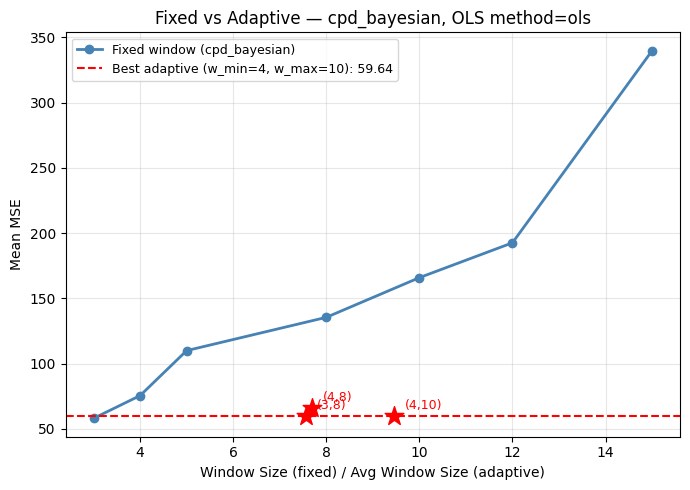

In [13]:
# --- Comparison plot: best adaptive vs all fixed (cpd_bayesian) ---
fig, axes = plt.subplots(1, len(METHODS), figsize=(7 * len(METHODS), 5))
if len(METHODS) == 1:
    axes = [axes]

for ax, method in zip(axes, METHODS):
    # Fixed baseline
    fixed_summary = df_baseline[df_baseline['method'] == method].groupby('window_size')['mse'].mean()
    ax.plot(fixed_summary.index, fixed_summary.values, 'o-', color='steelblue',
            label='Fixed window (cpd_bayesian)', linewidth=2, markersize=6)

    # Best adaptive
    adap = df[df['method'] == method].groupby(['w_min', 'w_max'])['mse'].mean()
    best_idx = adap.idxmin()
    best_mse = adap.min()
    ax.axhline(y=best_mse, color='red', linestyle='--', linewidth=1.5,
               label=f'Best adaptive (w_min={best_idx[0]}, w_max={best_idx[1]}): {best_mse:.2f}')

    # Top 3 adaptive configs
    top3 = adap.nsmallest(3)
    for (wmin, wmax), mse_val in top3.items():
        avg_ws = df[(df['method'] == method) & (df['w_min'] == wmin) &
                    (df['w_max'] == wmax)]['avg_window_size'].mean()
        ax.scatter(avg_ws, mse_val, marker='*', s=200, color='red', zorder=5)
        ax.annotate(f'({wmin},{wmax})', (avg_ws, mse_val),
                    textcoords='offset points', xytext=(8, 5), fontsize=9, color='red')

    ax.set_xlabel('Window Size (fixed) / Avg Window Size (adaptive)')
    ax.set_ylabel('Mean MSE')
    ax.set_title(f'Fixed vs Adaptive — cpd_bayesian, OLS method={method}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fixed_vs_adaptive_cpd_bayesian.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Visualize the best adaptive config on a sample dataset ---
for z0_val in [5, 80]:
    sample_files = [f for f in all_files if f'initial_value_{z0_val}' in f]
    if not sample_files:
        continue
    sample_file = sample_files[0]
    data_raw = pd.read_csv(os.path.join(ARRIVAL_DIR, sample_file))

    for method in METHODS:
        sub = df[(df['z0'] == z0_val) & (df['method'] == method)]
        if sub.empty:
            continue
        best = sub.loc[sub['mse'].idxmin()]
        w_min_best = int(best['w_min'])
        w_max_best = int(best['w_max'])
        print(f'\nZ0={z0_val}, method={method}: best w_min={w_min_best}, w_max={w_max_best}')
        print(f'  Visualizing on {sample_file}...')

        predictor = BOOLES_cpdPredictor(**BOCPD_PARAMS)
        predictor.adaptive_rolling_prediction(
            data_raw.copy(),
            w_min=w_min_best, w_max=w_max_best,
            method=method, plot=True,
            file_name=f'{sample_file} (Z0={z0_val})',
            lambda_=LAMBDA
        )

In [12]:
# --- Print final recommendations ---
print('\n' + '='*70)
print('GRID SEARCH RESULTS SUMMARY (cpd_bayesian + adaptive window)')
print('='*70)

for method in METHODS:
    print(f'\n--- OLS method: {method} ---')
    sub = summary[summary['method'] == method].sort_values('mse_mean')
    best = sub.iloc[0]
    print(f'  Best (w_min, w_max) = ({int(best["w_min"])}, {int(best["w_max"])})')
    print(f'  Mean MSE = {best["mse_mean"]:.4f} (+/- {best["mse_std"]:.4f})')
    print(f'  Mean MAE = {best["mae_mean"]:.4f}')
    print(f'  Mean RMSE = {best["rmse_mean"]:.4f}')
    print(f'  Avg window size used = {best["avg_ws_mean"]:.1f}')
    print(f'  Direction accuracy = {best["dir_acc_mean"]:.1f}%')

    # Compare to best fixed
    if len(df_baseline[df_baseline['method'] == method]) > 0:
        fixed_best = df_baseline[df_baseline['method'] == method].groupby('window_size')['mse'].mean()
        fb_ws = fixed_best.idxmin()
        fb_mse = fixed_best.min()
        improvement = (fb_mse - best['mse_mean']) / fb_mse * 100
        print(f'  Best fixed: ws={fb_ws}, MSE={fb_mse:.4f}')
        print(f'  Improvement over best fixed: {improvement:+.1f}%')


GRID SEARCH RESULTS SUMMARY (cpd_bayesian + adaptive window)

--- OLS method: ols ---
  Best (w_min, w_max) = (4, 10)
  Mean MSE = 59.6417 (+/- 96.7211)
  Mean MAE = 4.3966
  Mean RMSE = 5.9301
  Avg window size used = 9.4
  Direction accuracy = 54.3%
  Best fixed: ws=3, MSE=58.1278
  Improvement over best fixed: -2.6%
